# ⚛️ Tutorial Qiskit: Circuitos, Medição e Simuladores AER

Este tutorial apresenta os primeiros passos no Qiskit, cobrindo a criação de circuitos, como realizar medições e como utilizar o ecossistema **Qiskit Aer** para simulações ideais e com ruído.

---

## 1. Importando as Bibliotecas

Com o Qiskit moderno, a biblioteca Aer é o motor de simulação local.

In [5]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import atlas_mpl_style as ampl
import warnings
ampl.use_atlas_style()
plt.rcParams['font.family'] = 'DeJavu Sans'
plt.rcParams['font.serif'] = ['Times New Roman']
warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# 2. Create a Matplotlib figure and axes
def plot_histogram_counts( counts, title="", color=None, legend=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_histogram(counts, title=title, ax=ax, color=color, legend=legend)
    ax.set_ylabel('Counts', fontsize=20, loc='top')
    ax.set_ylim([0,600])
    plt.grid(False)
    plt.show()

## 2. Criando um Circuito Quântico

No Qiskit, um `QuantumCircuit` é a estrutura central. Vamos criar um estado GHZ de 3 qubits ($|000\rangle + |111\rangle$).

In [11]:
# GHZ state: h(0) + cx(0,1) + cx(0,2)
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

# Adicionando medições
qc.measure([0, 1, 2], [0, 1, 2])

# Desenho visual
print(qc.draw("text"))

     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 


## 3. Conhecendo os Simuladores do Qiskit AER

O Aer oferece diversos backends e métodos de simulação.

In [12]:
# Listando todos os backends disponíveis através do Aer
for backend in Aer.backends():
    print(f"- {backend.name}")

- aer_simulator
- aer_simulator_statevector
- aer_simulator_density_matrix
- aer_simulator_stabilizer
- aer_simulator_matrix_product_state
- aer_simulator_extended_stabilizer
- aer_simulator_unitary
- aer_simulator_superop
- qasm_simulator
- statevector_simulator
- unitary_simulator


## 4. Simulação Ideal (Sem Ruído)

Vamos rodar o circuito GHZ usando o `AerSimulator` padrão.

     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 
Resultados: {'000': 504, '111': 520}


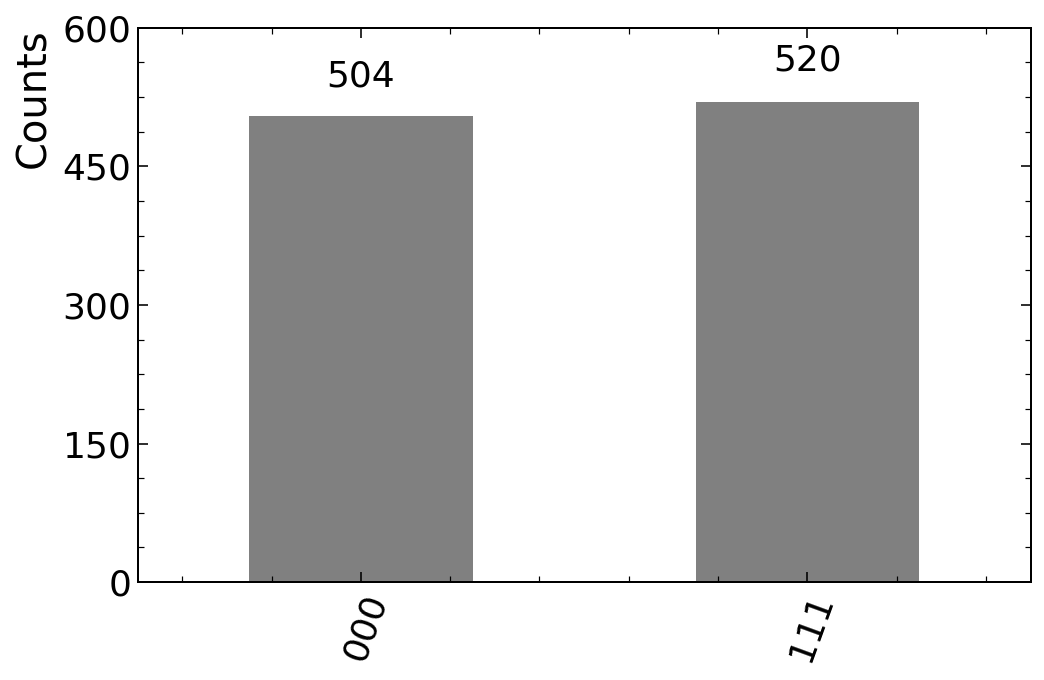

In [13]:
# Backend simulador local
sim_ideal = AerSimulator()

# Preparando para execução (transpilação)
qc_transpiled = transpile(qc, sim_ideal)

print(qc_transpiled.draw("text"))

# Executando (1024 shots)
result_ideal = sim_ideal.run(qc_transpiled).result()
counts_ideal = result_ideal.get_counts()

print(f"Resultados: {counts_ideal}")
plot_histogram_counts(counts_ideal, color='gray')

## 5. Simulação com Modelo de Ruído (Noise Model)

Agora, vamos criar um modelo de ruído customizado (ou importar de um device real) para ver como o circuito se degrada. Tipos Comuns de Ruído Quântico:

### Relaxação Térmica (Tempos $T_1$ e $T_2$)

Este é o limite físico mais fundamental.

* **Relaxação ($T_1$):** O tempo que um qubit leva para perder sua energia e decair do estado $|1\rangle$ de volta para $|0\rangle$.
* **Desfocagem/Desfrazagem ($T_2$):** O tempo que leva para a relação de "fase" em uma superposição ser perdida. Pense nisso como o qubit ficando "fora de sincronia".

### Erro de Despolarização

Um tipo geral de erro onde, com uma certa probabilidade $p$, o estado do qubit é substituído por um estado completamente aleatório (ruído branco). Isso é frequentemente usado como um modelo simplificado para erros de portas lógicas (gates).

### Erros de Bit-Flip e Phase-Flip

* **Bit-Flip (Inversão de Bit):** O qubit acidentalmente inverte de $|0\rangle$ para $|1\rangle$ ou vice-versa.
* **Phase-Flip (Inversão de Fase):** O sinal do qubit se inverte (ex: $|+\rangle$ torna-se $|-\rangle$), destruindo os padrões de interferência.

### Erro de Medição (Erro de Leitura)

Ocorre quando o qubit estava, na verdade, no estado $|0\rangle$, mas o hardware informa incorretamente que ele está no estado $|1\rangle$.

> **Nota:** Estamos definindo um ruído de inversão de bit (bit-flip) em todas as portas de qubit único.

Counts com alto ruído: {'101': 85, '001': 62, '100': 71, '110': 67, '111': 295, '011': 86, '010': 83, '000': 275}


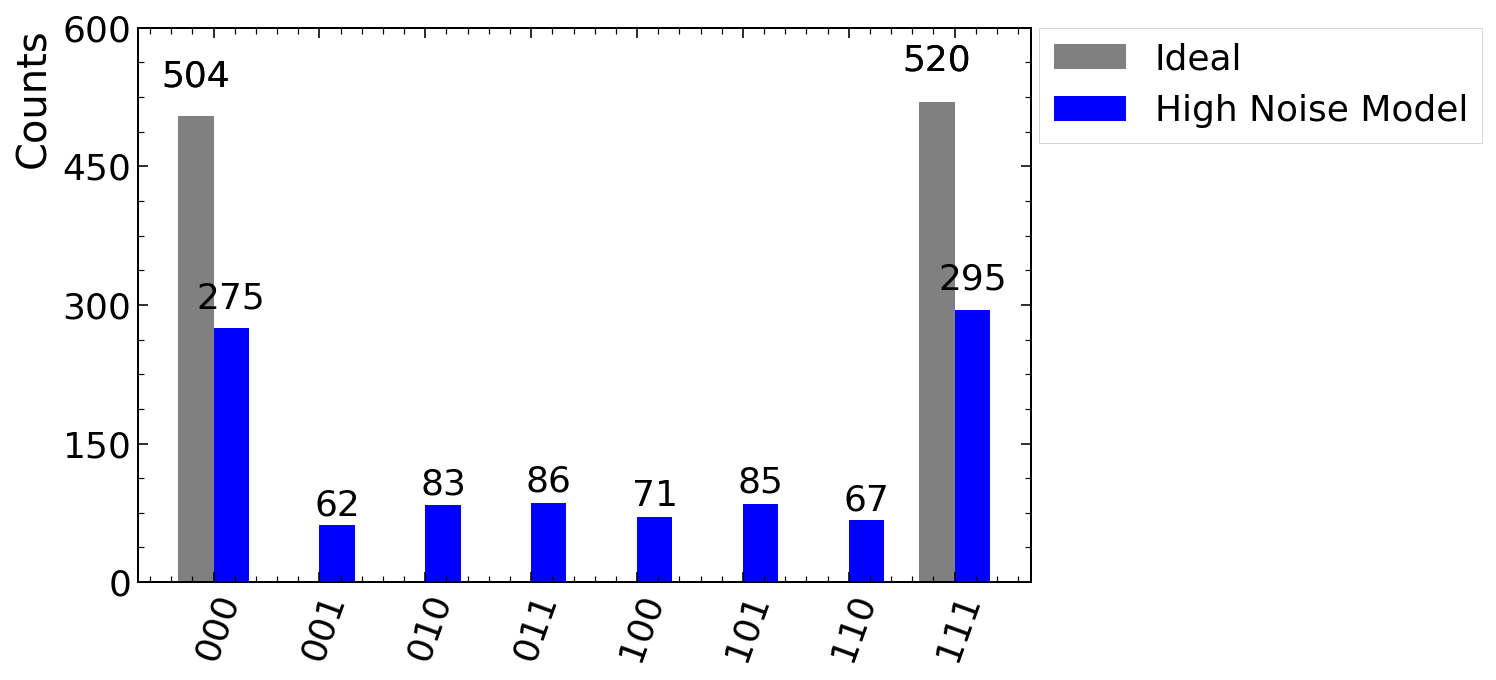

In [14]:
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error, ReadoutError

# Para produzir counts em quase todas as bitstrings, vamos aumentar significativamente o ruído
# e adicionar erros de leitura (readout) e erros em portas CNOT.

bit_flip_p = 0.15
phase_flip_p = 0.15
depol_p_2q = 0.1
readout_p = 0.15

# 1. Definimos erro de Bit-Flip e Phase-Flip para portas de 1 qubit
bit_flip = pauli_error([('X', bit_flip_p), ('I', 1 - bit_flip_p)])
phase_flip = pauli_error([('Z', phase_flip_p), ('I', 1 - phase_flip_p)])
single_q_error = bit_flip.compose(phase_flip)

# 2. Definimos erro de despolarização para portas de 2 qubits (CNOT)
two_q_error = depolarizing_error(depol_p_2q, 2)

# 3. Definimos erro de medição (Readout Error)
# Matriz de probabilidade: P(read 0 | state 0) = 1-p, P(read 1 | state 0) = p, etc.
read_err = ReadoutError([[1 - readout_p, readout_p], [readout_p, 1 - readout_p]])

# Criamos o modelo de ruído e adicionamos os erros
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(single_q_error, ['h', 'u1', 'u2', 'u3'])
noise_model.add_all_qubit_quantum_error(two_q_error, ['cx'])
noise_model.add_all_qubit_readout_error(read_err)

# Criamos o simulador com o modelo de ruído
sim_noise = AerSimulator(noise_model=noise_model)

# Transpilamos e executamos
qc_trans_noise = transpile(qc, sim_noise)
result_noise = sim_noise.run(qc_trans_noise, shots=1024).result()
counts_noise = result_noise.get_counts()

print(f"Counts com alto ruído: {counts_noise}")
plot_histogram_counts([counts_ideal, counts_noise], legend=['Ideal', 'High Noise Model'], color=['gray', 'blue'])


### 6 Exemplo: Simulação MPS com 20 Qubits

O método `matrix_product_state` é ideal para circuitos com baixo emaranhamento ou estruturas específicas (como cadeias 1D), permitindo simular muito mais qubits do que o método `statevector` (que escala exponencialmente).

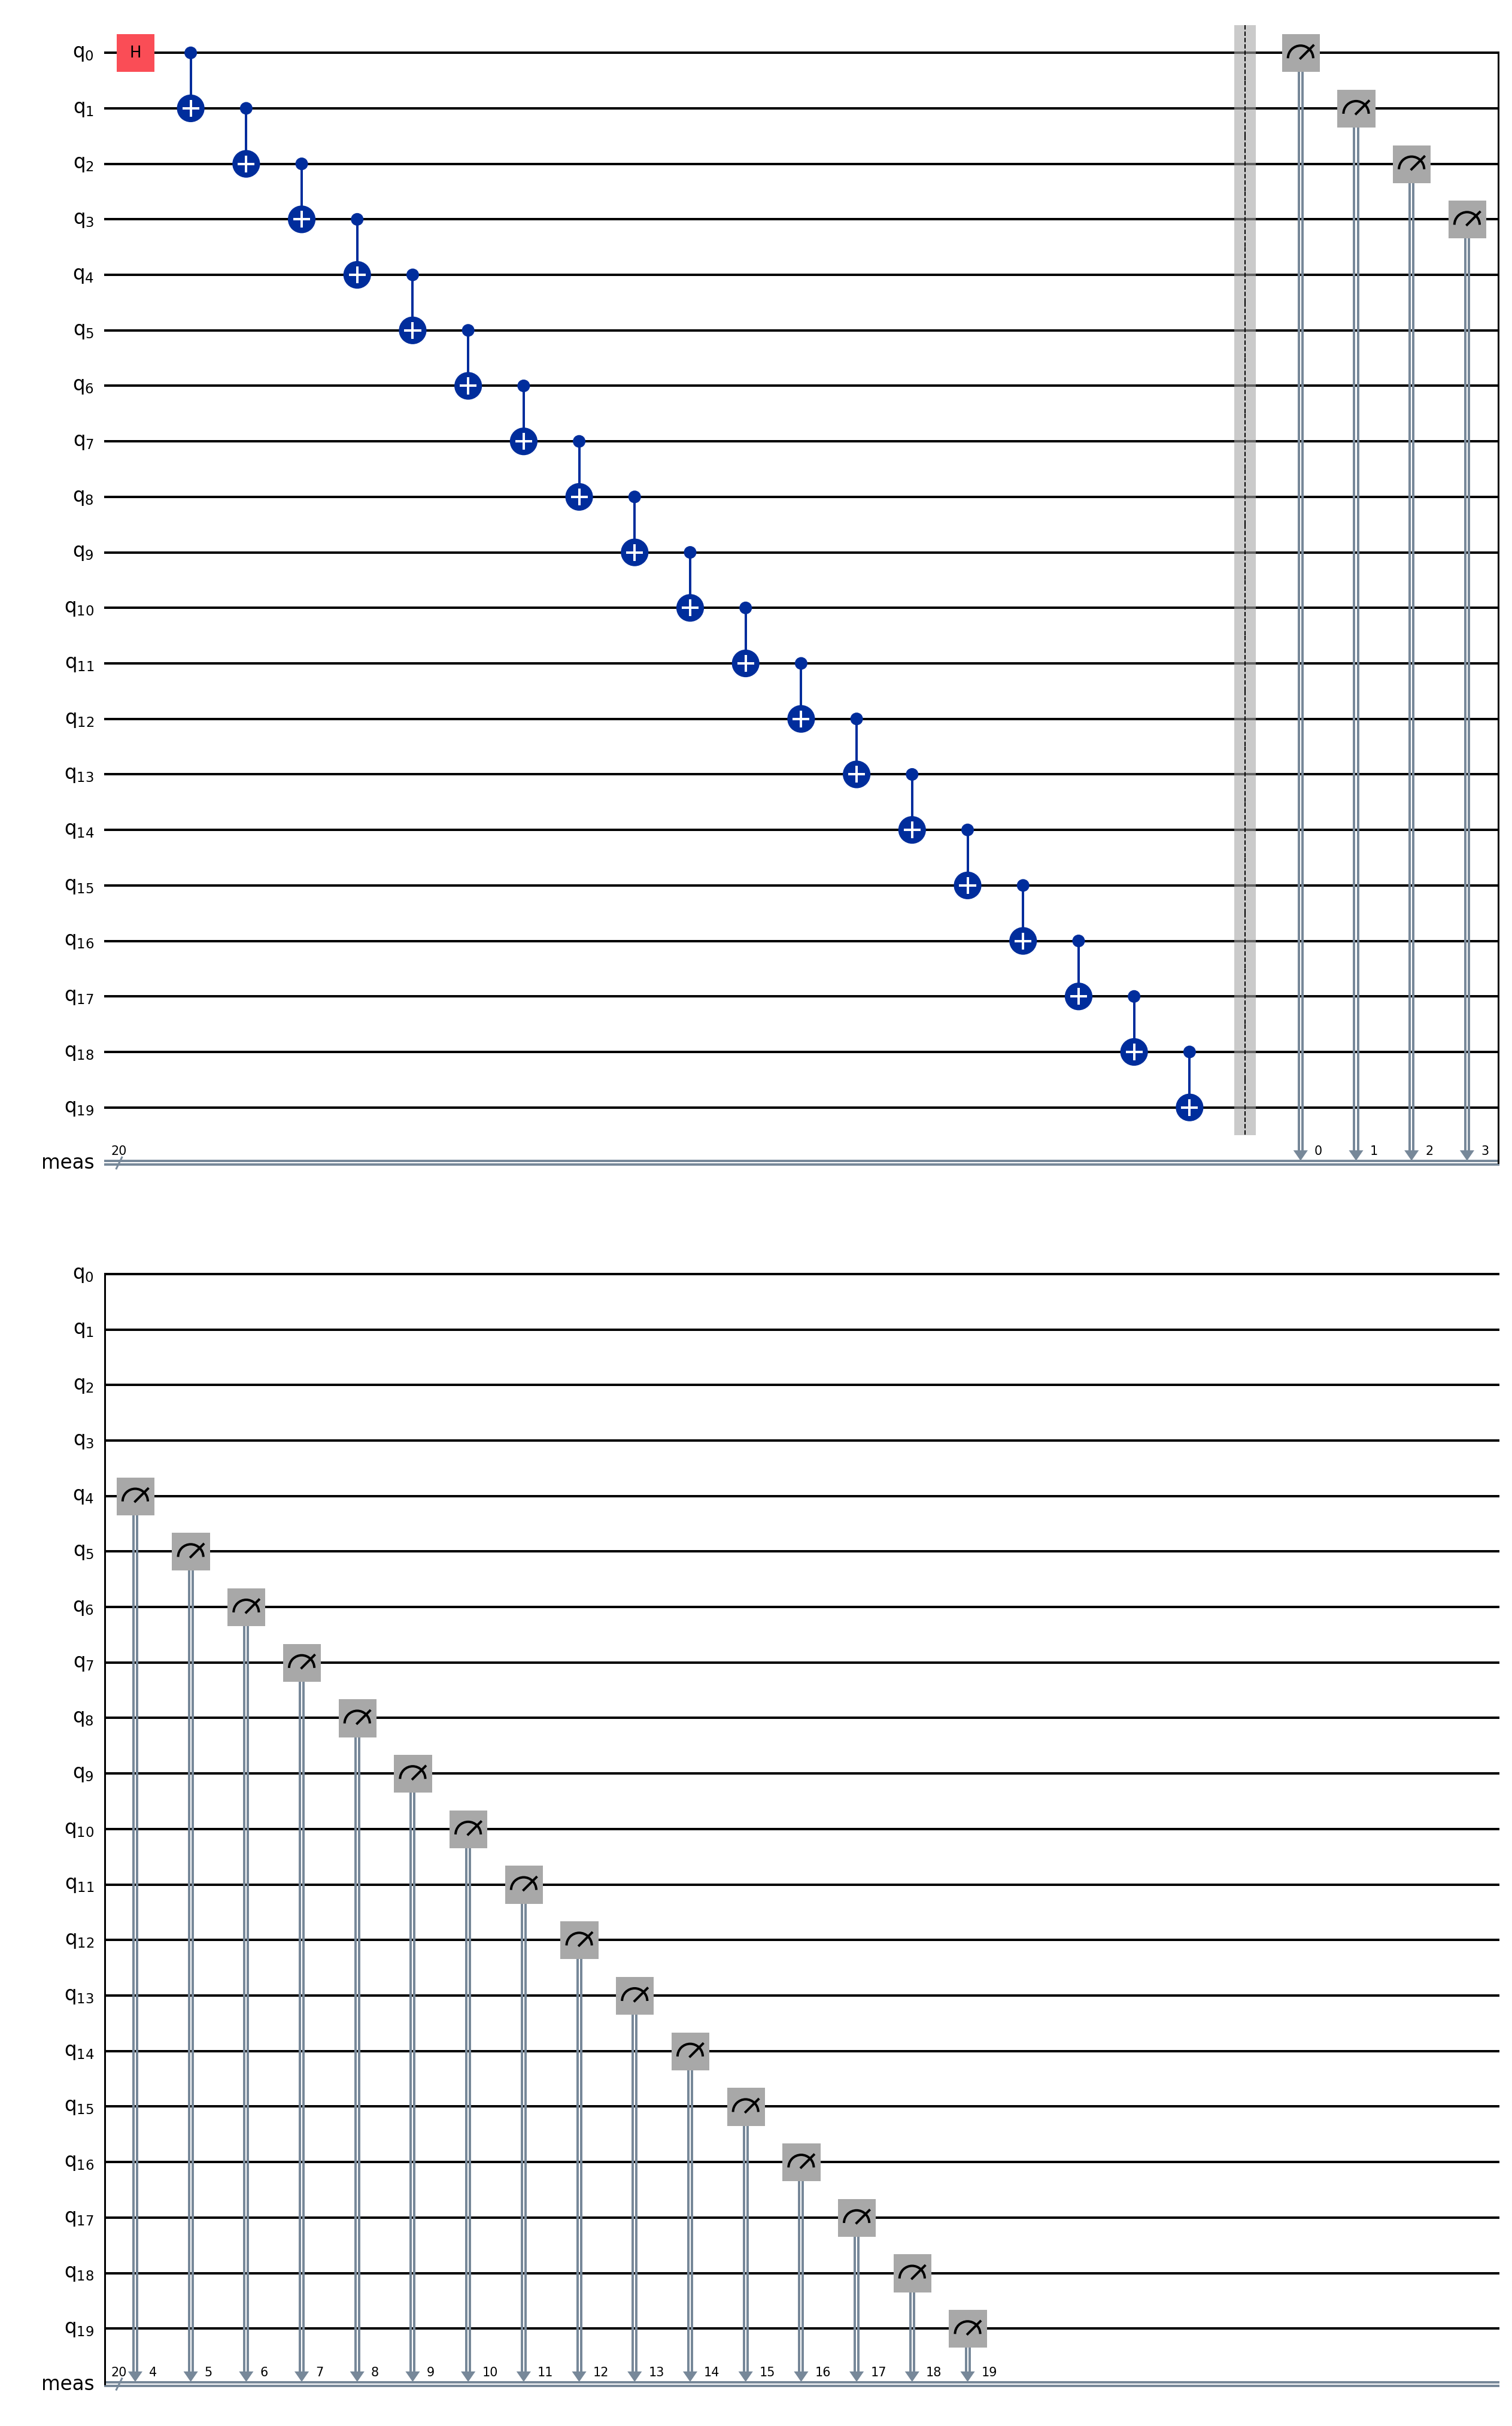

In [26]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# 1. Criando um circuito de 20 qubits (GHZ state)
num_qubits = 20
qc_mps = QuantumCircuit(num_qubits)
qc_mps.h(0)
for i in range(num_qubits - 1):
    qc_mps.cx(i, i+1)
qc_mps.measure_all()
qc_mps.draw(output='mpl')



In [17]:
# 2. Simulação Ideal usando MPS
sim_mps_ideal = AerSimulator(method='matrix_product_state')
tqc_mps_ideal = transpile(qc_mps, sim_mps_ideal)
counts_mps_ideal = sim_mps_ideal.run(tqc_mps_ideal, shots=1024).result().get_counts()

print(f"Simulação MPS Ideal concluída para {num_qubits} qubits.")
print(counts_mps_ideal)

Simulação MPS Ideal concluída para 20 qubits.
{'00000000000000000000': 526, '11111111111111111111': 498}


In [27]:

# 3. Simulação com Ruído usando MPS
# Reutilizando o noise_model definido anteriormente (ele se aplica a todas as portas)
sim_mps_noise = AerSimulator(method='matrix_product_state', noise_model=noise_model)
tqc_mps_noise = transpile(qc_mps, sim_mps_noise)
counts_mps_noise = sim_mps_noise.run(tqc_mps_noise, shots=1024).result().get_counts()

print(f"Simulação MPS com Ruído concluída para {num_qubits} qubits.")
#print(counts_mps_noise)

Simulação MPS com Ruído concluída para 20 qubits.


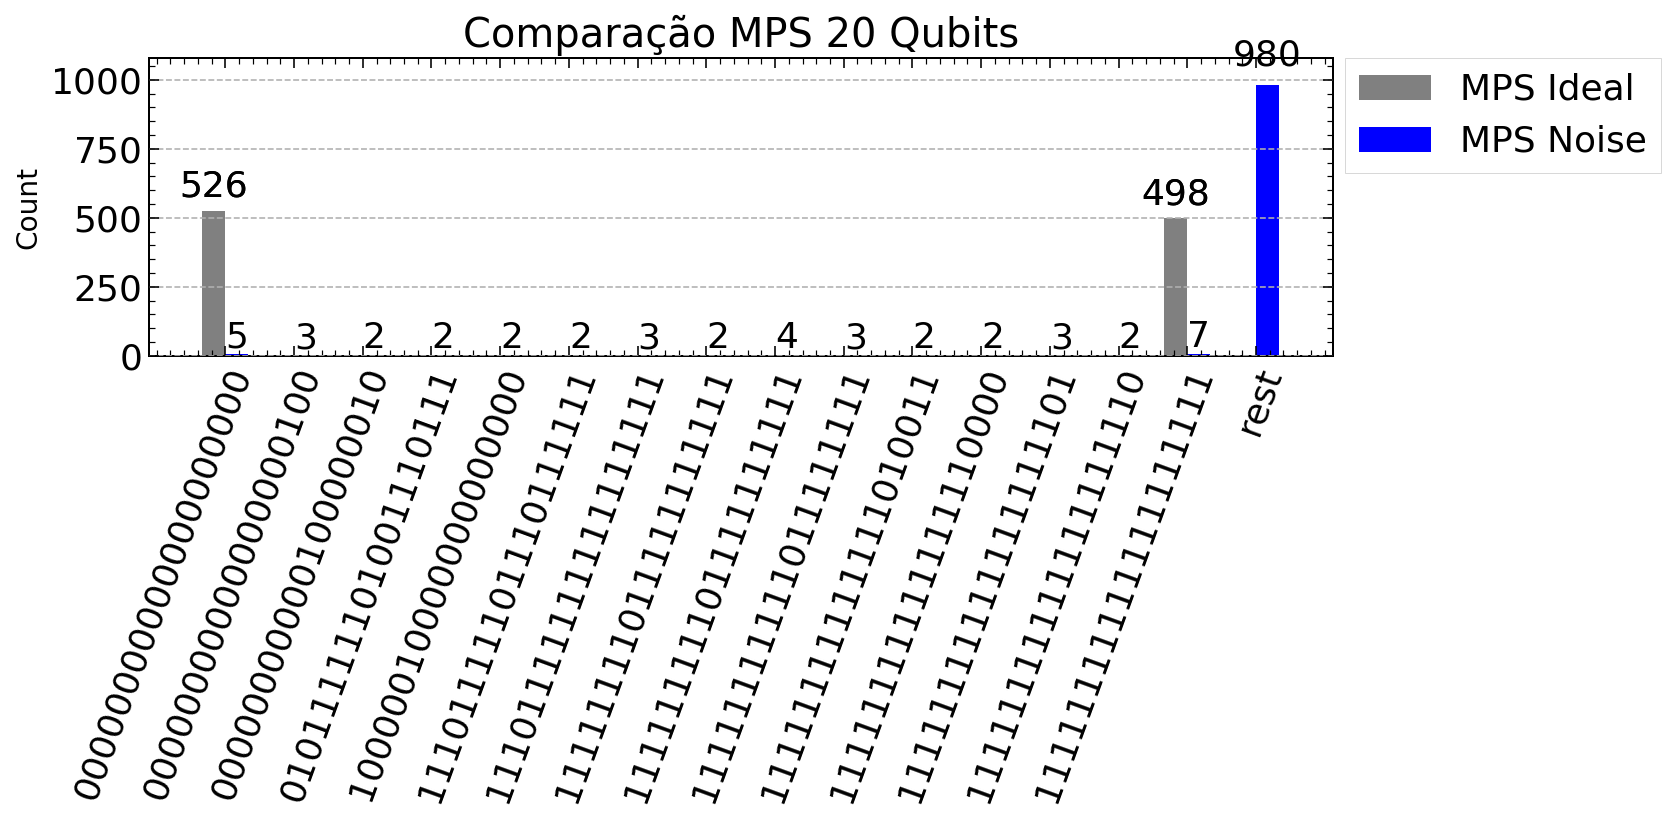

In [28]:
plot_histogram([counts_mps_ideal, counts_mps_noise], 
               legend=['MPS Ideal', 'MPS Noise'], 
               title=f"Comparação MPS {num_qubits} Qubits",
               number_to_keep=15,
               color=['gray', 'blue'],
               figsize=(12, 6))